In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in df.columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"Data Type: {df[col].dtype}")
    print(f"Unique Values ({df[col].nunique()}):")
    print(df[col].unique())
    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False))


Column: customerID
Data Type: object
Unique Values (7043):
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Value Counts:
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

Column: gender
Data Type: object
Unique Values (2):
['Female' 'Male']

Value Counts:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Column: SeniorCitizen
Data Type: int64
Unique Values (2):
[0 1]

Value Counts:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Column: Partner
Data Type: object
Unique Values (2):
['Yes' 'No']

Value Counts:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Column: Dependents
Data Type: object
Unique Values (2):
['No' 'Yes']

Value Counts:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Column: tenure
Data Type: int64
Uniqu

<Axes: >

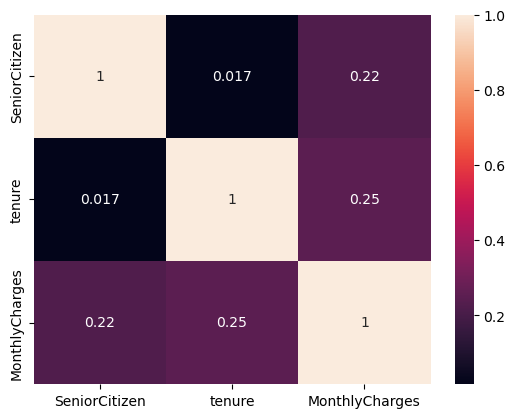

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

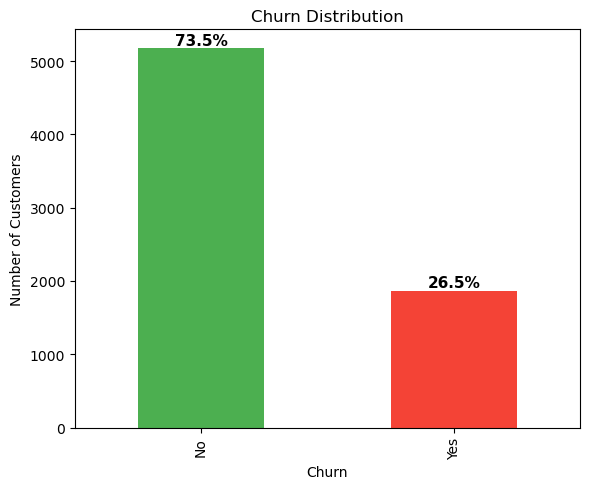

In [10]:
counts = df['Churn'].value_counts()
total = counts.sum()

ax = counts.plot(
    kind='bar',
    color=['#4CAF50', '#F44336'],
    figsize=(6, 5)
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for i, count in enumerate(counts):
    percentage = (count / total) * 100
    ax.text(
        i,
        count + 50,                 
        f'{percentage:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

#### Insights
 - Around 26.5% of customers have churned, indicating a moderately imbalanced dataset.
 - Most customers remain with the company, so evaluation metrics like F1-score and ROC-AUC are more suitable than accuracy.
 - Class imbalance should be considered during model training.

In [11]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

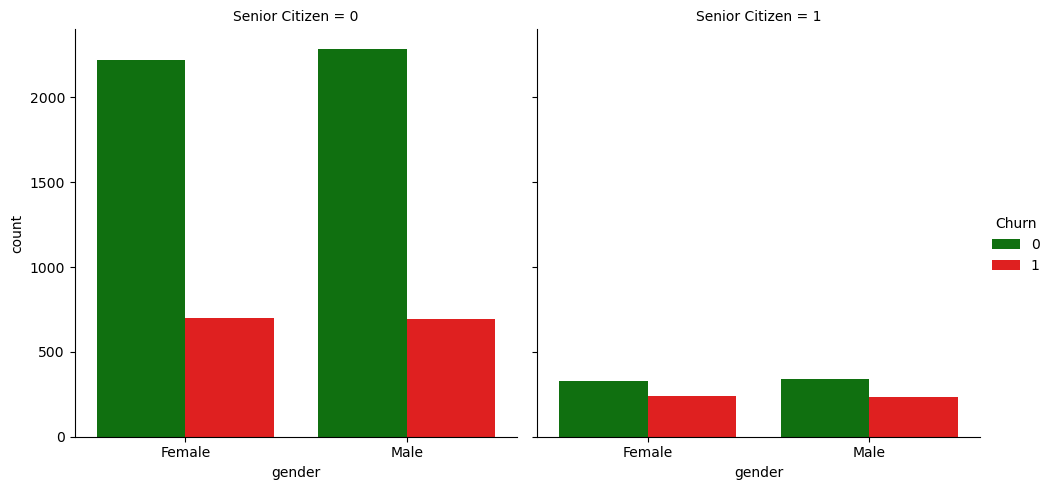

In [12]:
g = sns.catplot(
    data=df,
    x='gender',
    hue='Churn',
    col='SeniorCitizen',
    kind='count',
    palette=['green', 'red'],
    height=5,
    aspect=1
)

g.set_titles("Senior Citizen = {col_name}")
plt.show()

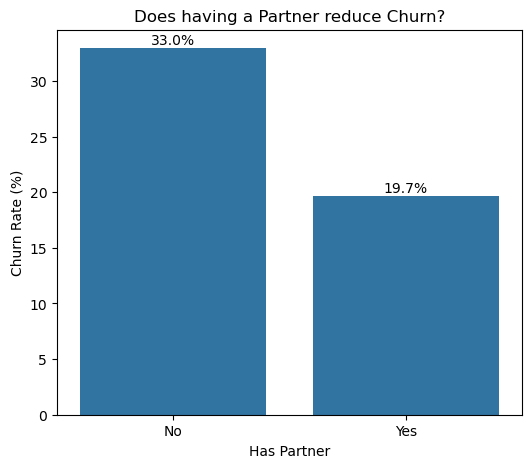

In [13]:
churn_rate = (
    pd.crosstab(df['Partner'], df['Churn'], normalize='index') * 100
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=churn_rate.index,
    y=churn_rate[1]
)

plt.title('Does having a Partner reduce Churn?')
plt.xlabel('Has Partner')
plt.ylabel('Churn Rate (%)')

for i, value in enumerate(churn_rate[1]):
    plt.text(i, value + 0.3, f'{value:.1f}%', ha='center')

plt.show()

#### Insights
 - Customers without a partner are more likely to churn.
 - Customers with a partner tend to remain with the company longer.

In [14]:
churn_rate = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)*100

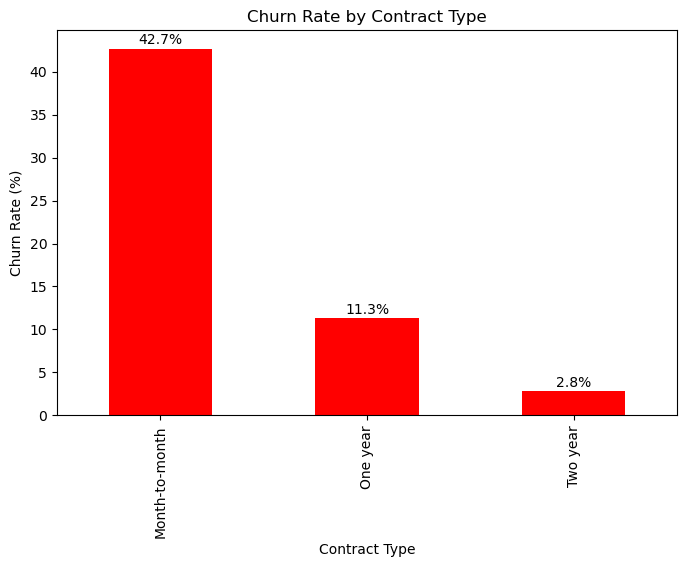

In [15]:
churn_rate.plot(
    kind='bar',
    color='red',
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(churn_rate):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha='center')

plt.show()

#### Insights
 - Customers with Month-to-Month contracts have the highest churn rate.
 - Customers with One-Year and Two-Year contracts are much more likely to stay.
 - Longer contracts improve customer retention.

In [16]:
churn_rate = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)*100

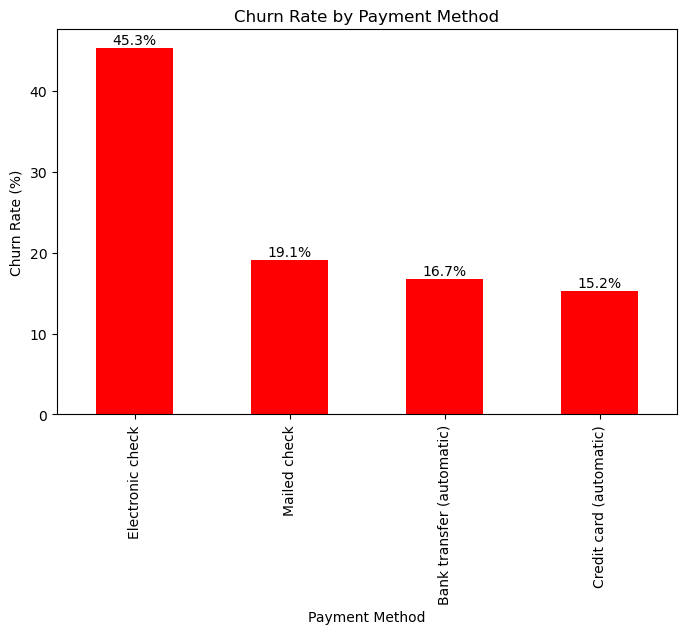

In [17]:
churn_rate.plot(
    kind='bar',
    color='red',
    figsize=(8,5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(churn_rate):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha='center')

plt.show()

#### Insights
 - Customers using Electronic Check have the highest churn rate.
 - Automatic payment methods are associated with lower churn.
 - Promoting automatic payments may help reduce churn.

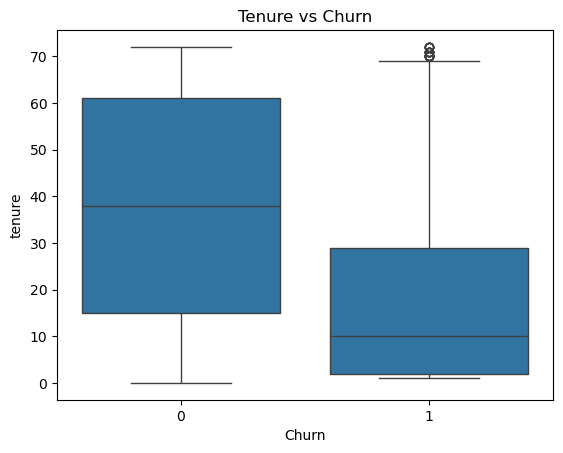

In [18]:
sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title("Tenure vs Churn")
plt.show()

#### Insights
 - Customers with shorter tenure are more likely to churn.
 - Churn decreases as customer tenure increases.
 - The first year is the most critical period for retention.

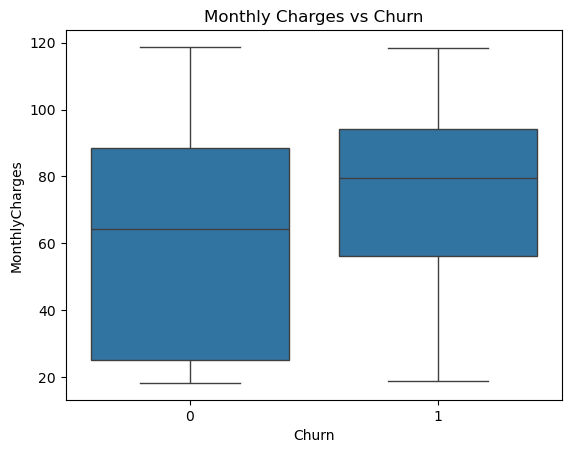

In [19]:
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title("Monthly Charges vs Churn")
plt.show()

#### Insights
 - Churned customers generally pay higher monthly charges.
 - Higher monthly costs may increase customer dissatisfaction and churn.

In [20]:
churn_rate = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)*100

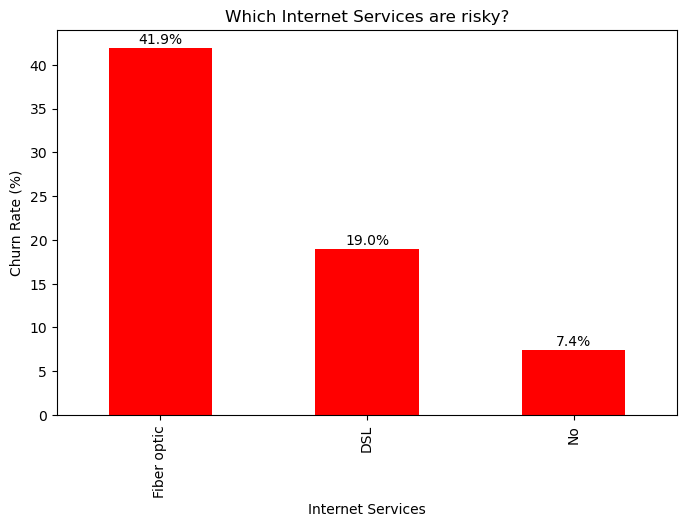

In [21]:
churn_rate.plot(
    kind='bar',
    color='red',
    figsize=(8,5)
)

plt.title("Which Internet Services are risky?")
plt.xlabel("Internet Services")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(churn_rate):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha='center')

plt.show()

#### Insights
 - Fiber Optic customers have the highest churn rate.
 - Customers without internet service have the lowest churn.
 - Fiber Optic customers should be prioritized for retention strategies.

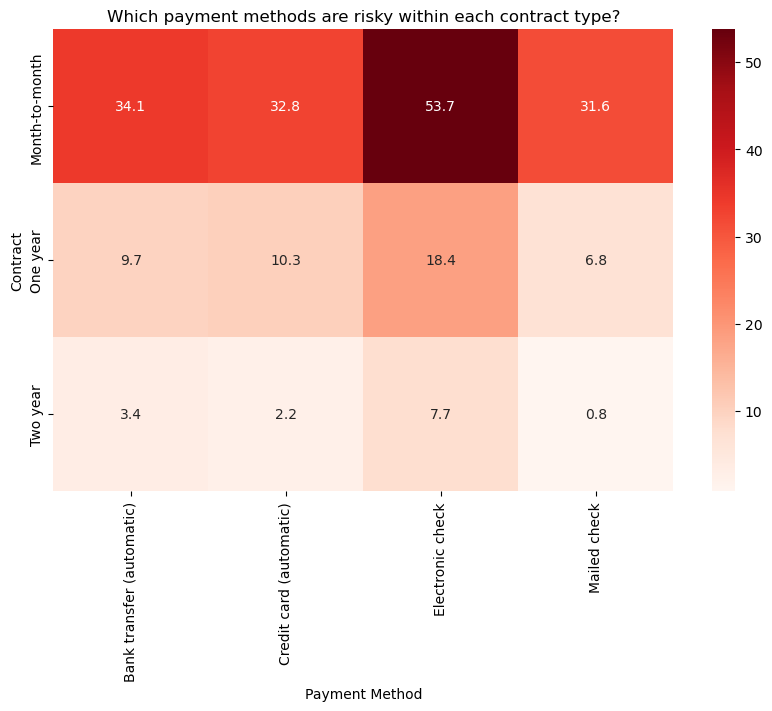

In [22]:
churn_rate = (
    df.groupby(['Contract', 'PaymentMethod'])['Churn']
      .mean()
      .unstack() * 100
)

plt.figure(figsize=(10,6))

sns.heatmap(
    churn_rate,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Which payment methods are risky within each contract type?")
plt.xlabel("Payment Method")
plt.ylabel("Contract")

plt.show()

#### Insights
 - Month-to-Month + Electronic Check has the highest churn rate.
 - Two-Year + Automatic Payment shows the strongest customer retention.
 - Combining these features may improve predictive performance.

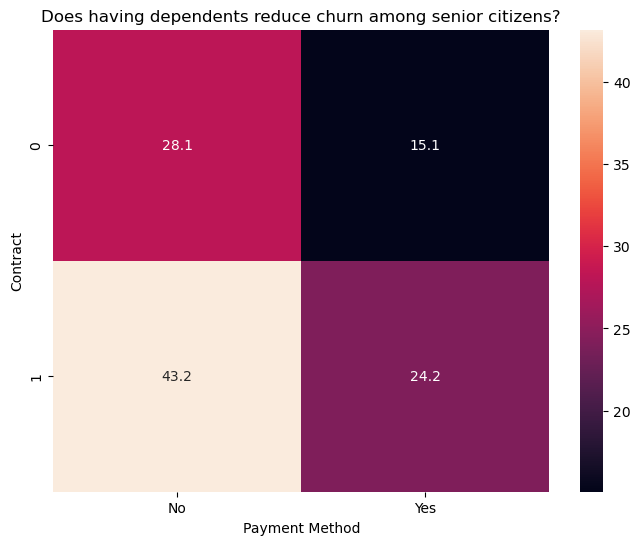

In [23]:
churn_rate = (
    df.groupby(['SeniorCitizen', 'Dependents'])['Churn']
      .mean()
      .unstack() * 100
)

plt.figure(figsize=(8,6))

sns.heatmap(
    churn_rate,
    annot=True,
    fmt=".1f"
)

plt.title("Does having dependents reduce churn among senior citizens?")
plt.xlabel("Payment Method")
plt.ylabel("Contract")

plt.show()

#### Insights
 - Senior citizens without dependents have the highest churn rate.
 - Having dependents reduces churn, especially among senior citizens.
 - Family-related factors appear to improve customer retention.

In [24]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [28]:
df['TotalCharges'].fillna(df['MonthlyCharges'])

df['TotalCharges'].isnull().sum()

np.int64(0)

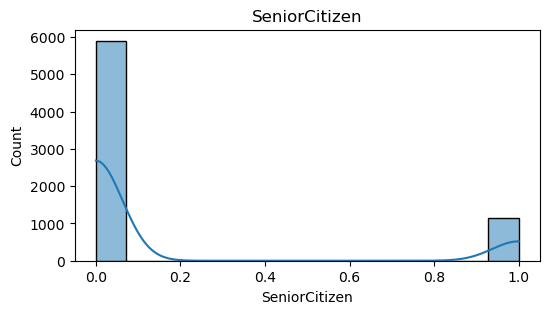

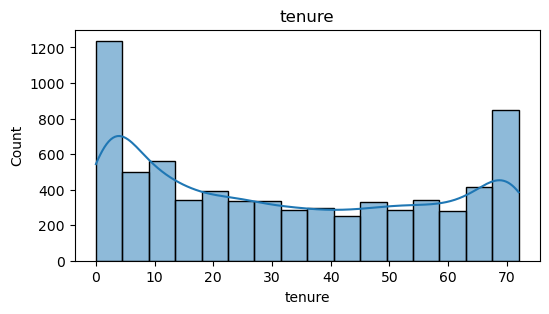

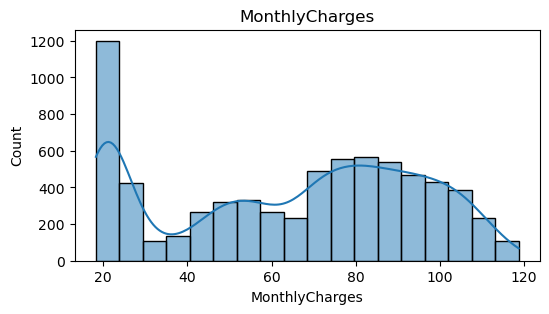

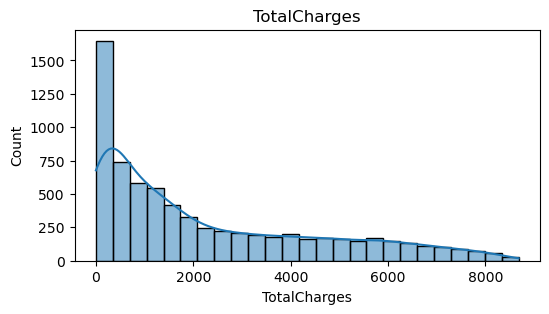

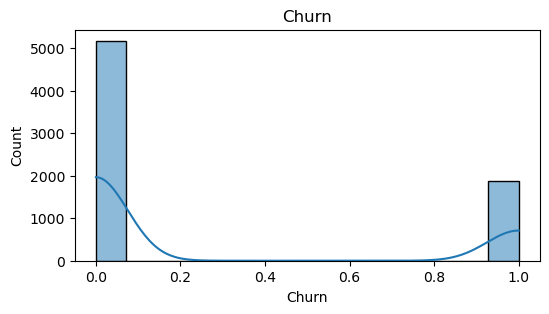

In [29]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(x=df[col], kde=True)
    plt.title(col)
    plt.show()

### Overall EDA Summary
#### Key Findings
 - The dataset has a moderately imbalanced target variable, with approximately 26.5% of customers churning.
 - Contract Type is the strongest indicator of churn, with Month-to-Month customers showing the highest risk.
 - Customers paying through Electronic Check are significantly more likely to churn than those using automatic payment methods.
 - Customers with short tenure have a much higher probability of leaving, making the first year of service the most important retention period.
 - Higher Monthly Charges are associated with increased churn, indicating possible price sensitivity.
 - Fiber Optic users have the highest churn among internet service types.
 - Customers without partners and Senior Citizens without dependents represent higher-risk customer groups.
 - The combination of Month-to-Month contracts and Electronic Check payments identifies the highest-risk customer segment.